# Linear Regression on Real Data

We'll fit a linear model to real housing data using **gradient descent**.

**MSE** (Mean Squared Error) measures how far our predictions are from the truth — on average, squared.
The **gradient** of MSE tells us which direction to nudge the weights to reduce the error.
**Gradient descent** repeatedly takes small steps in the negative gradient direction until the loss converges.

In [1]:
# %%
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_openml
import pandas as pd

In [2]:
# %%
def neuron2(x, w):
    return x@w

## Loading the Dataset

In [3]:
# %%
boston = fetch_openml(name="boston", version=1, as_frame=True)

In [4]:
# %%
df = boston.frame

In [5]:
# %%
df

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,MEDV
0,0.00632,18.0,2.31,0,0.538,6.575,65.2,4.0900,1,296.0,15.3,396.90,4.98,24.0
1,0.02731,0.0,7.07,0,0.469,6.421,78.9,4.9671,2,242.0,17.8,396.90,9.14,21.6
2,0.02729,0.0,7.07,0,0.469,7.185,61.1,4.9671,2,242.0,17.8,392.83,4.03,34.7
3,0.03237,0.0,2.18,0,0.458,6.998,45.8,6.0622,3,222.0,18.7,394.63,2.94,33.4
4,0.06905,0.0,2.18,0,0.458,7.147,54.2,6.0622,3,222.0,18.7,396.90,5.33,36.2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
501,0.06263,0.0,11.93,0,0.573,6.593,69.1,2.4786,1,273.0,21.0,391.99,9.67,22.4
502,0.04527,0.0,11.93,0,0.573,6.120,76.7,2.2875,1,273.0,21.0,396.90,9.08,20.6
503,0.06076,0.0,11.93,0,0.573,6.976,91.0,2.1675,1,273.0,21.0,396.90,5.64,23.9
504,0.10959,0.0,11.93,0,0.573,6.794,89.3,2.3889,1,273.0,21.0,393.45,6.48,22.0


## Visualizing the Data

Text(0, 0.5, 'MEDV')

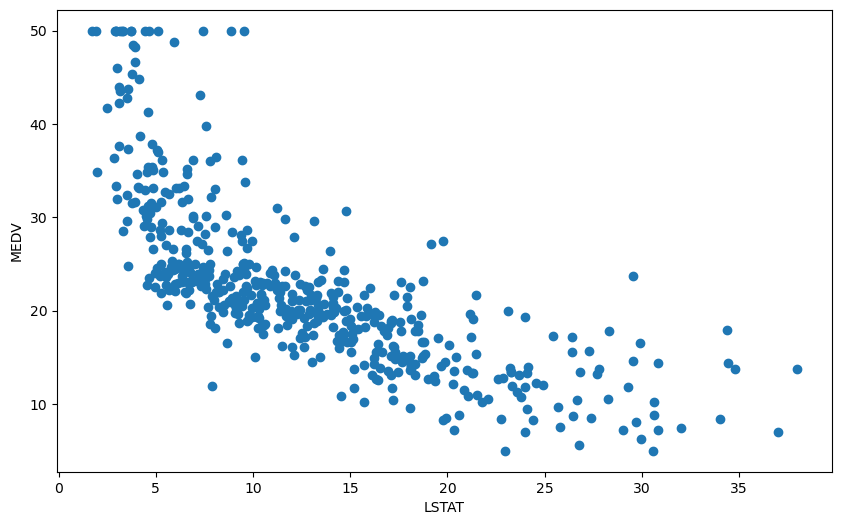

In [6]:
# %%
plt.figure(figsize=(10, 6))
plt.scatter(df['LSTAT'], df['MEDV'])
plt.xlabel('LSTAT')
plt.ylabel('MEDV')

## Fitting a Line Manually

In [7]:
# %%
x_1 = df["LSTAT"].values
x_b = np.ones_like(x_1)
X_train = np.vstack([x_1, x_b]).T
y_train = df['MEDV'].values

In [8]:
# %%
w = np.array([..., ...])
y_pred = neuron2(X_train, w)

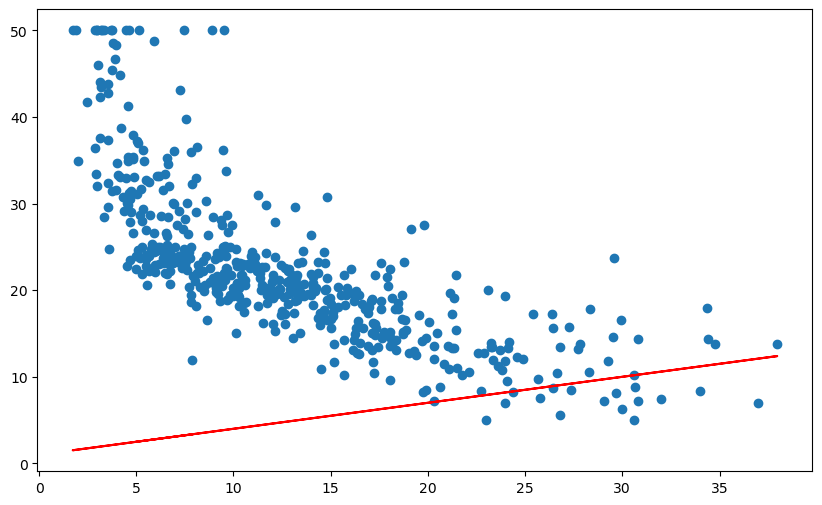

In [9]:
# %%
plt.figure(figsize=(10, 6))
plt.scatter(df['LSTAT'], df['MEDV'])
plt.plot(x_1, y_pred, c='r')

## Mean Squared Error
MSE = (1/N) Σ (y_true - y_pred)². Smaller is better.

In [10]:
# %%
def mse(y_actual, y_predicted):
    return np.mean(...)

In [11]:
# %%
def l_mse(X, y, w):
    y_pred = neuron2(X, w)
    return ...

In [12]:
# %%
l_mse(X_train, y_train, w)

np.float64(432.6082625434783)

## Comparing Models

In [13]:
# %%
w2 = np.array([0.22925899, 1.12375])
w3 = np.array([3.22925899, 0.12375])

In [14]:
w2_loss = l_mse(X_train, y_train, w2)
print(f"Model 1 Loss: {w2_loss:.2f}")

Model 1 Loss: 451.82


In [15]:
w3_loss = l_mse(X_train, y_train, w3)
print(f"Model 2 Loss: {w3_loss:.2f}")

Model 2 Loss: 1267.87


## MSE Gradient
The gradient tells us the direction of steepest increase in loss.
We move **opposite** to the gradient to decrease loss.

In [16]:
# %%
def mse_gradient(X, y, w):
    y_pred = neuron2(X, w)
    gradient = -(2/len(y)) * ... @ (...)
    return gradient

In [17]:
# %%
mse_gradient(X_train, y_train, w2)

array([-348.33216531,  -37.01645565])

In [18]:
# %%
mse_gradient(X_train, y_train, w3)

array([892.32564062,  36.9019238 ])

## Gradient Descent

In [19]:
# %%

[4.08264395 6.11632919] 2780.4346008831653
[3.94223467 6.1092809 ] 2569.487333092366
[3.80776833 6.10258934] 2376.027679719862
[3.67899324 6.09623939] 2198.6057799986743
[3.55566838 6.0902166 ] 2035.8919780344029
[3.43756291 6.0845071 ] 1886.6668568748978
[3.32445581 6.07909762] 1749.8120988340158
[3.21613537 6.07397545] 1624.3021035664929
[3.11239889 6.06912842] 1509.1963010704096
[3.01305224 6.06454488] 1403.6321020022654
[2.91790949 6.06021367] 1306.818432466441
[2.82679261 6.05612409] 1218.0298048215154
[2.7395311  6.05226591] 1136.6008800634215
[2.65596169 6.04862932] 1061.9214810298463
[2.575928   6.04520495] 993.4320190492517
[2.49928031 6.04198379] 930.6192997566976
[2.42587521 6.03895725] 873.0126766405533
[2.35557538 6.03611706] 820.180523490472
[2.2882493  6.03345535] 771.7269993072
[2.22377104 6.03096455] 727.2890814268338
[2.16201999 6.02863742] 686.5338446224356
[2.10288065 6.02646702] 649.1559657895458
[2.0462424  6.02444671] 614.8754355129131
[1.99199934 6.02257013] 583

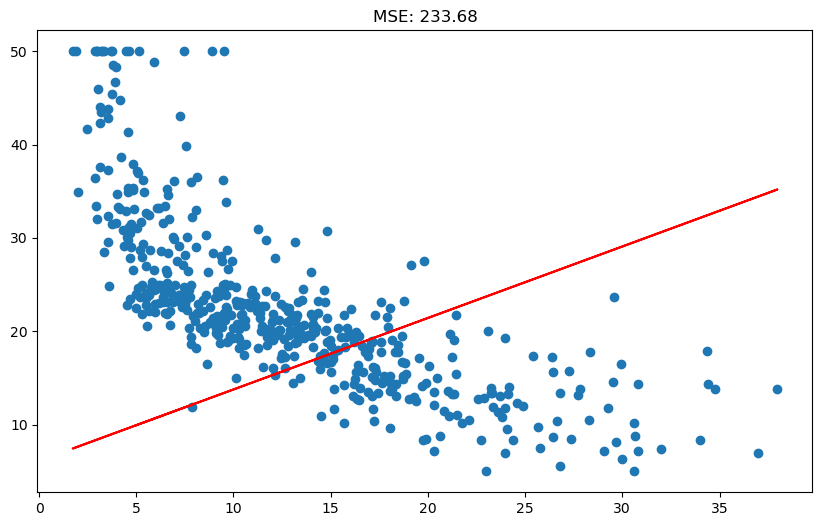

In [20]:
plt.figure(figsize=(10, 6))
w = np.array([4.22925899, 6.12375])
plt.scatter(df['LSTAT'], df['MEDV'])

iterations = 140
learning_rate = 0.0001
losses = []
for _ in range(iterations):
    gradient = ...
    loss = ...
    losses.append(loss)
    w = w - ... * ...
    print(w, loss)

y_pred = neuron2(X_train, w)
mse_val = mse(y_train, y_pred)
plt.title(f"MSE: {mse_val:.2f}")
plt.plot(x_1, y_pred, c='r')

## Loss Curve
Plotting MSE over iterations shows how the model converges.

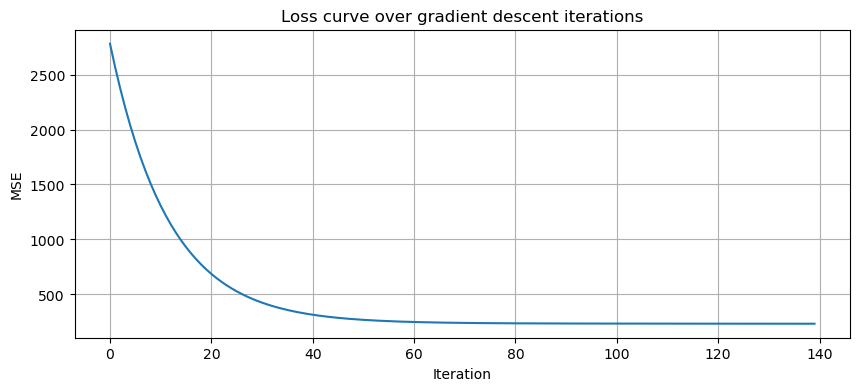

In [21]:
# %%
plt.figure(figsize=(10, 4))
plt.plot(losses)
plt.xlabel("Iteration")
plt.ylabel("MSE")
plt.title("Loss curve over gradient descent iterations")
plt.grid(True)

## Train/Test Split
So far we trained and evaluated on the same data. To measure **generalization**,
we split the data into train and test sets.

In [22]:
# %%
from sklearn.model_selection import train_test_split

In [23]:
# %%
X_tr, X_te, y_tr, y_te = train_test_split(X_train, y_train, test_size=0.2, random_state=42)

In [24]:
# %%
w = np.array([4.22925899, 6.12375])
train_losses = []
test_losses = []
for _ in range(iterations):
    gradient = mse_gradient(X_tr, y_tr, w)
    w = w - ... * ...
    train_losses.append(l_mse(X_tr, y_tr, w))
    test_losses.append(l_mse(X_te, y_te, w))

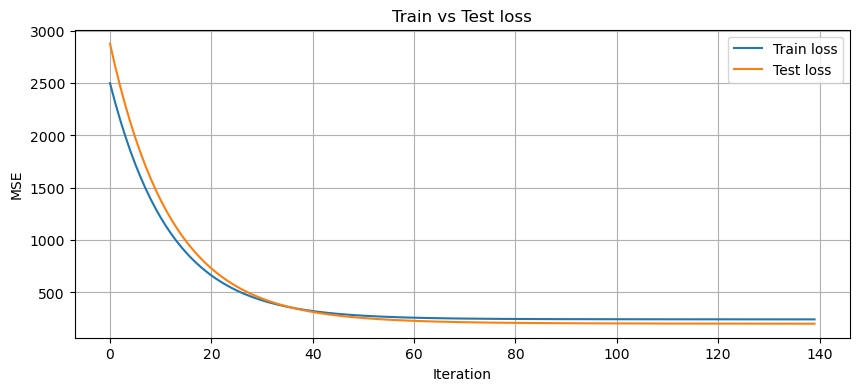

In [25]:
# %%
plt.figure(figsize=(10, 4))
plt.plot(train_losses, label="Train loss")
plt.plot(test_losses, label="Test loss")
plt.xlabel("Iteration")
plt.ylabel("MSE")
plt.title("Train vs Test loss")
plt.legend()
plt.grid(True)

In [26]:
# %%
print(f"Final train MSE: {train_losses[-1]:.2f}")
print(f"Final test MSE:  {test_losses[-1]:.2f}")

Final train MSE: 242.16
Final test MSE:  200.62
